In [5]:
import numpy as np
import matplotlib.pyplot as plt


print("XOR DATASET PREPARATION")


X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

print("\nXOR Truth Table:")
print("Input 1 Input 2  XOR Output")
for i in range(len(X)):
    print(f"   {int(X[i][0])}     {int(X[i][1])}       {int(y[i][0])}")





XOR DATASET PREPARATION

XOR Truth Table:
Input 1 Input 2  XOR Output
   0     0       0
   0     1       1
   1     0       1
   1     1       0


In [6]:
# IMPLEMENTATION 1: KERAS (TensorFlow High-Level API)


print("KERAS (TensorFlow High-Level API)")

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

# Build model
keras_model = Sequential([
    Dense(4, input_shape=(2,), activation='relu', name='hidden'),
    Dense(1, activation='sigmoid', name='output')
], name='Keras_XOR')

# Compile
keras_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nModel Architecture:")
keras_model.summary()

# Train
print("\nTraining Keras model")
keras_history = keras_model.fit(X, y, epochs=1000, batch_size=4, verbose=0)

# Evaluate
keras_predictions = keras_model.predict(X, verbose=0)
keras_classes = (keras_predictions > 0.5).astype(int)

print("\nKeras - Prediction Results:")
print("Input 1 Input 2 Actual Predicted Probability")
for i in range(len(X)):
    print(f"   {int(X[i][0])}    {int(X[i][1])}    {int(y[i][0])}     {keras_classes[i][0]}   {keras_predictions[i][0]:.6f}")

keras_accuracy = np.mean(keras_classes == y.astype(int))
print(f"\nKeras Accuracy: {keras_accuracy*100:.2f}%")
print(f"Final Loss: {keras_history.history['loss'][-1]:.6f}")

KERAS (TensorFlow High-Level API)

Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Keras_XOR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)


Training Keras model

Keras - Prediction Results:
Input 1 Input 2 Actual Predicted Probability
   0    0    0     0   0.300793
   0    1    1     1   0.786494
   1    0    1     1   0.870325
   1    1    0     0   0.119965

Keras Accuracy: 100.00%
Final Loss: 0.216456


In [7]:
# IMPLEMENTATION 2: PyTorch


print("IMPLEMENTATION 2: PyTorch")


import torch
import torch.nn as nn
import torch.optim as optim

# Define PyTorch model
class XOR_MLP(nn.Module):
    def __init__(self):
        super(XOR_MLP, self).__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

# Create model
pytorch_model = XOR_MLP()

# Define loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.01)

# Convert data to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

print("\nModel Architecture:")
print(pytorch_model)

# Train
print("\nTraining PyTorch model...")
pytorch_losses = []
for epoch in range(1000):
    # Forward pass
    outputs = pytorch_model(X_tensor)
    loss = criterion(outputs, y_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    pytorch_losses.append(loss.item())

# Evaluate
with torch.no_grad():
    pytorch_predictions = pytorch_model(X_tensor).numpy()
    pytorch_classes = (pytorch_predictions > 0.5).astype(int)

print("\nPyTorch - Prediction Results:")
print("Input 1 Input 2 Actual Predicted Probability")
for i in range(len(X)):
    print(f"   {int(X[i][0])}   {int(X[i][1])}    {int(y[i][0])}      {pytorch_classes[i][0]}     {pytorch_predictions[i][0]:.6f}")


pytorch_accuracy = np.mean(pytorch_classes == y.astype(int))
print(f"\nPyTorch Accuracy: {pytorch_accuracy*100:.2f}%")
print(f"Final Loss: {pytorch_losses[-1]:.6f}")


IMPLEMENTATION 2: PyTorch

Model Architecture:
XOR_MLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Training PyTorch model...

PyTorch - Prediction Results:
Input 1 Input 2 Actual Predicted Probability
   0   0    0      0     0.004440
   0   1    1      1     0.998575
   1   0    1      1     0.998422
   1   1    0      0     0.001499

PyTorch Accuracy: 100.00%
Final Loss: 0.002244


In [8]:
# IMPLEMENTATION 3: TensorFlow Low-Level API


print("IMPLEMENTATION 3: TensorFlow Low-Level API")


import tensorflow as tf

# Define model variables
tf.random.set_seed(42)
W1 = tf.Variable(tf.random.normal([2, 4]), name='W1')
b1 = tf.Variable(tf.zeros([4]), name='b1')
W2 = tf.Variable(tf.random.normal([4, 1]), name='W2')
b2 = tf.Variable(tf.zeros([1]), name='b2')

# Define forward pass
def forward_pass(x):
    hidden = tf.nn.relu(tf.matmul(x, W1) + b1)
    output = tf.nn.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

# Define loss function
def compute_loss(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))

# Optimizer
optimizer_tf = tf.optimizers.Adam(learning_rate=0.01)

print("\nModel Architecture:")
print(f"  Layer 1: Input(2) -Hidden(4) with ReLU")
print(f"  Layer 2: Hidden(4) -Output(1) with Sigmoid")
print(f"  Total parameters: {2*4 + 4 + 4*1 + 1} = 17")

# Train
print("\nTraining TensorFlow model")
tf_losses = []
for epoch in range(1000):
    with tf.GradientTape() as tape:
        predictions = forward_pass(X)
        loss = compute_loss(y, predictions)

    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer_tf.apply_gradients(zip(gradients, [W1, b1, W2, b2]))
    tf_losses.append(loss.numpy())

# Evaluate
tf_predictions = forward_pass(X).numpy()
tf_classes = (tf_predictions > 0.5).astype(int)

print("\nTensorFlow - Prediction Results:")
print("Input 1  Input 2 Actual Predicted Probability")
for i in range(len(X)):
    print(f"   {int(X[i][0])}    {int(X[i][1])}    {int(y[i][0])}     {tf_classes[i][0]}    {tf_predictions[i][0]:.6f}")


tf_accuracy = np.mean(tf_classes == y.astype(int))
print(f"\n TensorFlow Accuracy: {tf_accuracy*100:.2f}%")
print(f" Final Loss: {tf_losses[-1]:.6f}")





IMPLEMENTATION 3: TensorFlow Low-Level API

Model Architecture:
  Layer 1: Input(2) -Hidden(4) with ReLU
  Layer 2: Hidden(4) -Output(1) with Sigmoid
  Total parameters: 17 = 17

Training TensorFlow model

TensorFlow - Prediction Results:
Input 1  Input 2 Actual Predicted Probability
   0    0    0     0    0.004389
   0    1    1     1    0.997698
   1    0    1     1    0.999020
   1    1    0     0    0.004392

 TensorFlow Accuracy: 100.00%
 Final Loss: 0.003027


COMPARISON OF ALL THREE IMPLEMENTATIONS

Library              Accuracy        Final Loss     
Keras                100.00%       0.216456
PyTorch              100.00%   0.002244
TensorFlow           100.00%      0.003027


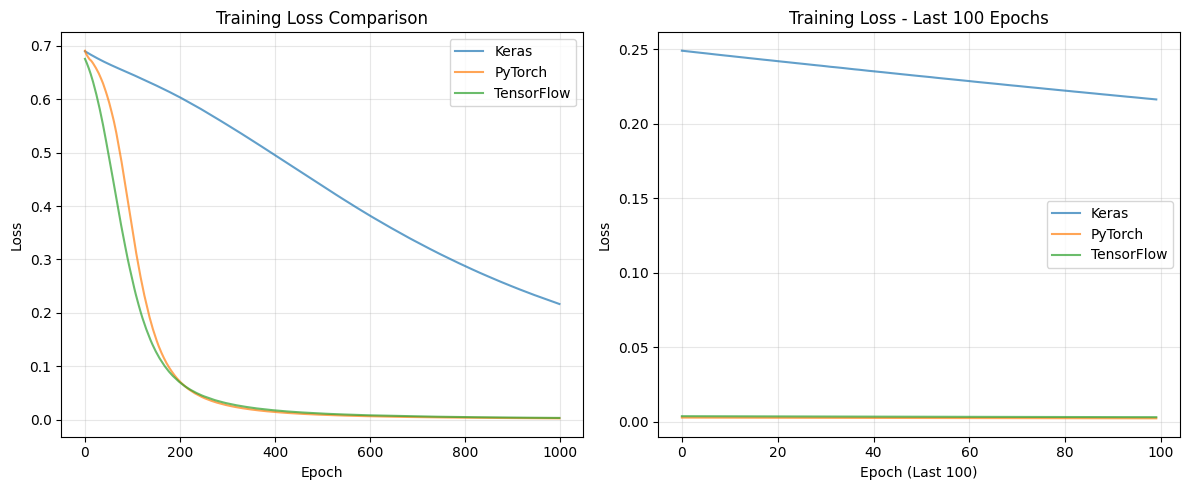

In [9]:
# COMPARISON AND VISUALIZATION

print("COMPARISON OF ALL THREE IMPLEMENTATIONS")


print(f"\n{'Library':<20} {'Accuracy':<15} {'Final Loss':<15}")
print(f"{'Keras':<20} {keras_accuracy*100:>6.2f}%     {keras_history.history['loss'][-1]:>10.6f}")
print(f"{'PyTorch':<20} {pytorch_accuracy*100:>6.2f}% {pytorch_losses[-1]:>10.6f}")
print(f"{'TensorFlow':<20} {tf_accuracy*100:>6.2f}%    {tf_losses[-1]:>10.6f}")


# Plot training loss for all three
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(keras_history.history['loss'], label='Keras', alpha=0.7)
plt.plot(pytorch_losses, label='PyTorch', alpha=0.7)
plt.plot(tf_losses, label='TensorFlow', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(keras_history.history['loss'][-100:], label='Keras', alpha=0.7)
plt.plot(pytorch_losses[-100:], label='PyTorch', alpha=0.7)
plt.plot(tf_losses[-100:], label='TensorFlow', alpha=0.7)
plt.xlabel('Epoch (Last 100)')
plt.ylabel('Loss')
plt.title('Training Loss - Last 100 Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()